In [1]:
# Step 1: Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler


In [3]:
# Step 2: Load Dataset

df = pd.read_csv('Live.csv')

print("Dataset Shape:", df.shape)

df.head()


Dataset Shape: (7050, 16)


,status_id,status_type,status_published,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,Column1,Column2,Column3,Column4
0,246675545449582_1649696485147474,video,4/22/2018 6:00,529,512,262,432,92,3,1,1,0,NaN,NaN,NaN,NaN
1,246675545449582_1649426988507757,photo,4/21/2018 22:45,150,0,0,150,0,0,0,0,0,NaN,NaN,NaN,NaN
2,246675545449582_1648730588577397,video,4/21/2018 6:17,227,236,57,204,21,1,1,0,0,NaN,NaN,NaN,NaN
3,246675545449582_1648576705259452,photo,4/21/2018 2:29,111,0,0,111,0,0,0,0,0,NaN,NaN,NaN,NaN
4,246675545449582_1645700502213739,photo,4/18/2018 3:22,213,0,0,204,9,0,0,0,0,NaN,NaN,NaN,NaN


In [4]:
# Step 3: Understand Dataset Structure

df.info()

# Observation:
# This helps identify data types and missing values.

<class 'pandas.DataFrame'>
RangeIndex: 7050 entries, 0 to 7049
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   status_id         7050 non-null   str    
 1   status_type       7050 non-null   str    
 2   status_published  7050 non-null   str    
 3   num_reactions     7050 non-null   int64  
 4   num_comments      7050 non-null   int64  
 5   num_shares        7050 non-null   int64  
 6   num_likes         7050 non-null   int64  
 7   num_loves         7050 non-null   int64  
 8   num_wows          7050 non-null   int64  
 9   num_hahas         7050 non-null   int64  
 10  num_sads          7050 non-null   int64  
 11  num_angrys        7050 non-null   int64  
 12  Column1           0 non-null      float64
 13  Column2           0 non-null      float64
 14  Column3           0 non-null      float64
 15  Column4           0 non-null      float64
dtypes: float64(4), int64(9), str(3)
memory usage: 881.4 K

In [5]:
# Step 4: Descriptive Statistics

df.describe()

# Observation:
# Engagement features show significant variation.
# Potential outliers are present in reactions, comments and shares.
# Column1–Column4 contain only missing values and can be dropped.

,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,Column1,Column2,Column3,Column4
count,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,0.0,0.0,0.0,0.0
mean,230.117163,224.356028,40.022553,215.043121,12.728652,1.289362,0.696454,0.243688,0.113191,NaN,NaN,NaN,NaN
std,462.625309,889.636820,131.599965,449.472357,39.972930,8.719650,3.957183,1.597156,0.726812,NaN,NaN,NaN,NaN
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
25%,17.000000,0.000000,0.000000,17.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
50%,59.500000,4.000000,0.000000,58.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
75%,219.000000,23.000000,4.000000,184.750000,3.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
max,4710.000000,20990.000000,3424.000000,4710.000000,657.000000,278.000000,157.000000,51.000000,31.000000,NaN,NaN,NaN,NaN


In [6]:
# Step 5: Check Missing Values

print(df.isnull().sum())

# Observation:
# No missing values were found in the main dataset columns.
# Column1, Column2, Column3 and Column4 contain 100% missing values.
# These columns will be removed during preprocessing.


status_id              0
status_type            0
status_published       0
num_reactions          0
num_comments           0
num_shares             0
num_likes              0
num_loves              0
num_wows               0
num_hahas              0
num_sads               0
num_angrys             0
Column1             7050
Column2             7050
Column3             7050
Column4             7050
dtype: int64


In [ ]:
# Step 6: Check Duplicate Rows

duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

# Observation:
# The dataset contains exactly 51 duplicate rows.


Duplicate Rows: 51


In [ ]:
# Step 7: Remove Duplicate Rows

df = df.drop_duplicates()

print("New Shape After Removing Duplicates:", df.shape)

# Observation:
# After removing 51 duplicate rows, the dataset has 6,999 rows.


New Shape After Removing Duplicates: (6999, 16)


In [ ]:
# Step 8: Remove Fully Empty Columns

df.drop(
    columns=['Column1', 'Column2', 'Column3', 'Column4'],
    inplace=True
)

print("New Shape After Removing Empty Columns:", df.shape)

# Observation:
# Dropping the 4 empty columns reduces the dataset to 6,999 rows and 12 columns.

New Shape After Removing Empty Columns: (6999, 12)


In [10]:
# Step 9: Check Data Types

print(df.dtypes)

# Observation:
# This helps identify categorical and numerical features.


status_id             str
status_type           str
status_published      str
num_reactions       int64
num_comments        int64
num_shares          int64
num_likes           int64
num_loves           int64
num_wows            int64
num_hahas           int64
num_sads            int64
num_angrys          int64
dtype: object


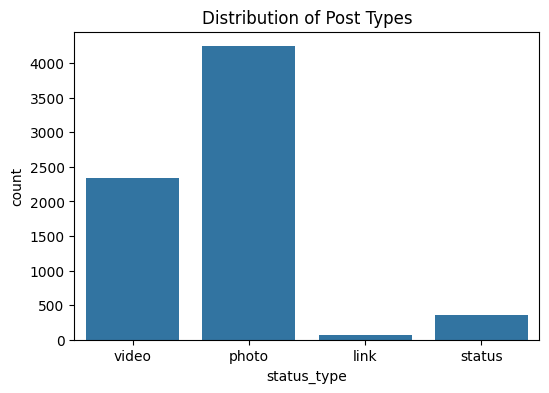

In [ ]:
# Step 10: Status Type Distribution
plt.figure(figsize=(6,4))

sns.countplot(x='status_type', data=df)

plt.title("Distribution of Post Types")

plt.show()

# Observation:
# Photo posts dominate with 4,244 posts — that is 60.6% of all content.
# Video posts are the second most common with 2,333 posts (33.3%).
# Status posts are rare with 359 posts (5.1%).
# Link posts are the rarest with only 63 posts (0.9%).

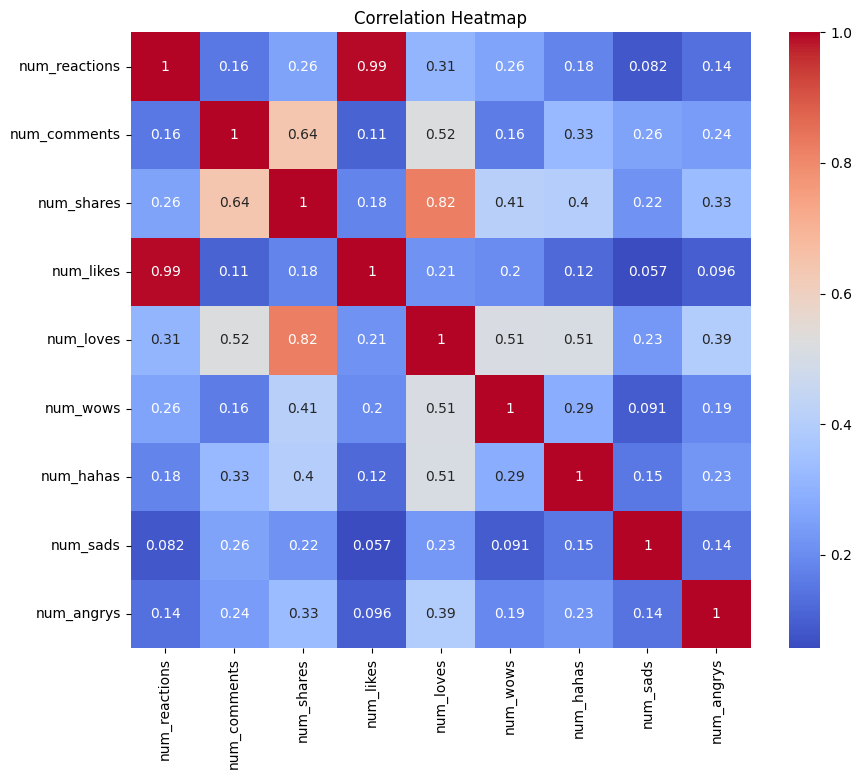

In [ ]:
# Step 11: Correlation Heatmap

num_cols = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,8))

sns.heatmap(
    num_cols.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

# Observation:
# num_likes and num_reactions have a near-perfect correlation of 0.99 
# num_shares and num_loves have a strong correlation of 0.82 
# num_comments and num_shares are moderately correlated (0.64) 
# num_sads and num_angrys have the lowest correlations overall 